In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('Cleaned_Netflix_Dataset.csv')

# Executive Dataset Summary
print("==================================================")
print("            NETFLIX DATASET OVERVIEW              ")
print("==================================================")
print(f"Total Content Items : {len(df):,}")
print(f"Total Columns       : {df.shape[1]}")
print(f"Movies Count        : {(df['type'] == 'Movie').sum():,} ({(df['type'] == 'Movie').mean()*100:.1f}%)")
print(f"TV Shows Count      : {(df['type'] != 'Movie').sum():,} ({(df['type'] != 'Movie').mean()*100:.1f}%)")
print(f"Unique Countries    : {df['country'].nunique()}")
print(f"Release Year Range  : {df['release_year'].min()} - {df['release_year'].max()}")
print("==================================================")

            NETFLIX DATASET OVERVIEW              
Total Content Items : 8,790
Total Columns       : 10
Movies Count        : 6,126 (69.7%)
TV Shows Count      : 2,664 (30.3%)
Unique Countries    : 86
Release Year Range  : 1925 - 2021


In [2]:
# Aggregate Key Metrics
top_country = df[df['country'] != 'Unknown']['country'].mode()[0]
top_rating = df['rating'].mode()[0]
most_common_genre = df['listed_in'].str.split(', ').explode().mode()[0]

print("--- KEY CONTENT PATTERNS ---")
print(f"• Dominant Market Hub : {top_country}")
print(f"• Dominant Rating     : {top_rating} (Mature Content)")
print(f"• Top Genre           : {most_common_genre}")

--- KEY CONTENT PATTERNS ---
• Dominant Market Hub : United States
• Dominant Rating     : TV-MA (Mature Content)
• Top Genre           : International Movies


/tmp/ipykernel_1348/3472325870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x='type', palette='Set2')
/tmp/ipykernel_1348/3472325870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
/tmp/ipykernel_1348/3472325870.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], x=top_ratings.index, y=top_ratings.values, palette='magma')


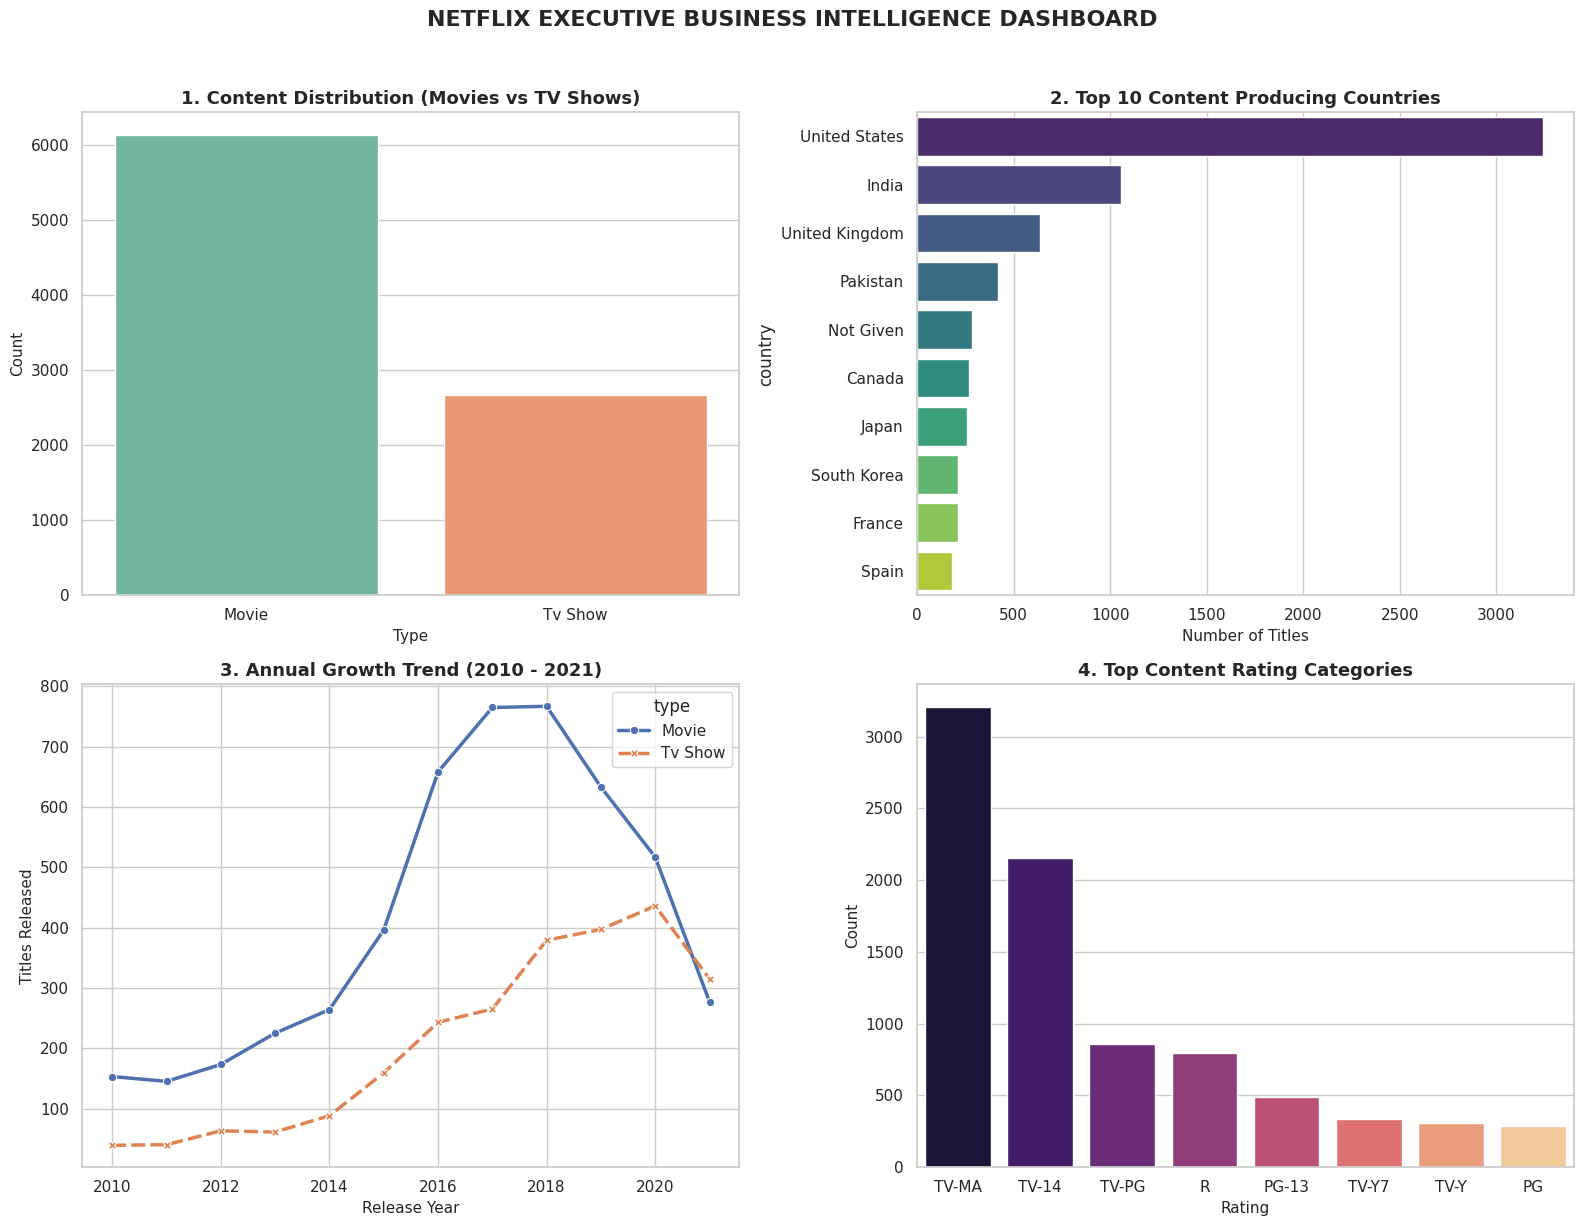

In [3]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Content Type Breakdown
sns.countplot(ax=axes[0, 0], data=df, x='type', palette='Set2')
axes[0, 0].set_title('1. Content Distribution (Movies vs TV Shows)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Type', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)

# Subplot 2: Top 10 Countries
top_10_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(ax=axes[0, 1], x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
axes[0, 1].set_title('2. Top 10 Content Producing Countries', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Number of Titles', fontsize=11)

# Subplot 3: Yearly Growth Trend (2010 - 2021)
recent_years = df[df['release_year'] >= 2010]
yearly_counts = recent_years.groupby(['release_year', 'type']).size().unstack(fill_value=0)
sns.lineplot(ax=axes[1, 0], data=yearly_counts, markers=True, linewidth=2.5)
axes[1, 0].set_title('3. Annual Growth Trend (2010 - 2021)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Release Year', fontsize=11)
axes[1, 0].set_ylabel('Titles Released', fontsize=11)

# Subplot 4: Top Content Ratings
top_ratings = df['rating'].value_counts().head(8)
sns.barplot(ax=axes[1, 1], x=top_ratings.index, y=top_ratings.values, palette='magma')
axes[1, 1].set_title('4. Top Content Rating Categories', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Rating', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)

plt.suptitle('NETFLIX EXECUTIVE BUSINESS INTELLIGENCE DASHBOARD', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# ---------------------------------------------------------
# 1. DYNAMIC BUSINESS METRICS CALCULATION
# ---------------------------------------------------------
total_catalog = len(df)

# Catalog Ratios
movie_ratio = (df['type'] == 'Movie').mean() * 100
tv_ratio = (df['type'] == 'Tv Show').mean() * 100

# Strategic Shift Post-2018
df_post_2018 = df[df['release_year'] >= 2018]
post_2018_tv_share = (df_post_2018['type'] == 'Tv Show').mean() * 100

# Geographic Diversification
us_share = (df['country'] == 'United States').mean() * 100
top_int_markets = df[(df['country'] != 'United States') & (~df['country'].isin(['Not Given', 'Unknown']))]['country'].value_counts().head(3)
top_int_str = ", ".join([f"{c} ({cnt:,})" for c, cnt in top_int_markets.items()])

# Demographic Targeting Ratios
mature_share = df['rating'].isin(['TV-MA', 'R', 'NC-17']).mean() * 100
teen_share = df['rating'].isin(['TV-14', 'PG-13']).mean() * 100
kids_share = df['rating'].isin(['TV-Y', 'TV-Y7', 'G', 'TV-PG', 'PG']).mean() * 100

# ---------------------------------------------------------
# 2. EXECUTIVE BUSINESS INSIGHTS OUTPUT
# ---------------------------------------------------------
print("=" * 80)
print("             NETFLIX STRATEGIC BUSINESS INSIGHTS & RECOMMENDATIONS         ")
print("=" * 80 + "\n")

print(f"1. CONTENT PORTFOLIO & STRATEGIC SHIFT:")
print(f"   • Historical Balance: Movies represent {movie_ratio:.1f}% of catalog inventory vs {tv_ratio:.1f}% for TV Shows.")
print(f"   • Strategic Shift   : In recent releases (2018–present), TV Shows expanded to {post_2018_tv_share:.1f}% of additions,")
print(f"                         reflecting subscriber retention focus on multi-episode series.\n")

print(f"2. GEOGRAPHIC EXPANSION & GLOBALIZATION:")
print(f"   • Core Domestic Share : The United States accounts for {us_share:.1f}% of overall productions.")
print(f"   • International Hubs  : Non-US content expansion is strongly driven by {top_int_str},")
print(f"                         supporting regional subscriber acquisition strategies.\n")

print(f"3. AUDIENCE DEMOGRAPHIC SEGMENTATION:")
print(f"   • Mature Audiences (TV-MA/R) : {mature_share:.1f}% of total library (dominant category).")
print(f"   • Teen/Young Adult (TV-14/PG13): {teen_share:.1f}% of total library.")
print(f"   • Family & Kids Content      : {kids_share:.1f}% of total library.\n")

print("4. EXECUTIVE RECOMMENDATIONS:")
print("   • Recommendation A: Expand investment in high-retention episodic TV series across international hubs.")
print("   • Recommendation B: Balance mature-heavy catalog with targeted family/kids programming to reduce churn.")
print("=" * 80)

             NETFLIX STRATEGIC BUSINESS INSIGHTS & RECOMMENDATIONS         

1. CONTENT PORTFOLIO & STRATEGIC SHIFT:
   • Historical Balance: Movies represent 69.7% of catalog inventory vs 30.3% for TV Shows.
   • Strategic Shift   : In recent releases (2018–present), TV Shows expanded to 41.0% of additions,
                         reflecting subscriber retention focus on multi-episode series.

2. GEOGRAPHIC EXPANSION & GLOBALIZATION:
   • Core Domestic Share : The United States accounts for 36.9% of overall productions.
   • International Hubs  : Non-US content expansion is strongly driven by India (1,057), United Kingdom (638), Pakistan (421),
                         supporting regional subscriber acquisition strategies.

3. AUDIENCE DEMOGRAPHIC SEGMENTATION:
   • Mature Audiences (TV-MA/R) : 45.6% of total library (dominant category).
   • Teen/Young Adult (TV-14/PG13): 30.1% of total library.
   • Family & Kids Content      : 20.8% of total library.

4. EXECUTIVE RECOMMENDATIONS:

In [5]:
import pandas as pd

# ---------------------------------------------------------
# 1. DYNAMIC METRIC CALCULATIONS
# ---------------------------------------------------------
total_titles = len(df)
movies_cnt = (df['type'] == 'Movie').sum()
tv_cnt = (df['type'] == 'Tv Show').sum()
movies_pct = (movies_cnt / total_titles) * 100
tv_pct = (tv_cnt / total_titles) * 100

# Top Country & Market Share
top_country = df[df['country'] != 'Unknown']['country'].mode()[0]
top_country_cnt = (df['country'] == top_country).sum()
top_country_pct = (top_country_cnt / total_titles) * 100

# Target Demographic Distribution
mature_cnt = df['rating'].isin(['TV-MA', 'R', 'NC-17']).sum()
mature_pct = (mature_cnt / total_titles) * 100

# Top Genre
top_genre = df['listed_in'].str.split(', ').explode().mode()[0]

# Historical Peak Analysis
peak_year = df[(df['release_year'] >= 2000) & (df['release_year'] <= 2021)]['release_year'].value_counts().idxmax()
peak_count = df['release_year'].value_counts().max()

# ---------------------------------------------------------
# 2. GENERATE KPI SCORECARD TABLE
# ---------------------------------------------------------
kpi_data = {
    "Key Performance Indicator": [
        "Total Portfolio Volume",
        "Movie Share",
        "TV Show Share",
        "Primary Production Market",
        "Mature Audience Content (TV-MA / R)",
        "Dominant Genre Category",
        "Peak Addition Release Year"
    ],
    "Value": [
        f"{total_titles:,} titles",
        f"{movies_cnt:,} ({movies_pct:.1f}%)",
        f"{tv_cnt:,} ({tv_pct:.1f}%)",
        f"{top_country} ({top_country_cnt:,} titles | {top_country_pct:.1f}%)",
        f"{mature_cnt:,} titles ({mature_pct:.1f}%)",
        f"{top_genre}",
        f"{peak_year} ({peak_count:,} titles)"
    ]
}

kpi_df = pd.DataFrame(kpi_data)

# ---------------------------------------------------------
# 3. EXECUTIVE REPORT OUTPUT
# ---------------------------------------------------------
print("=" * 80)
print("             NETFLIX EXECUTIVE BUSINESS ANALYTICAL REPORT              ")
print("=" * 80 + "\n")

print("[1. EXECUTIVE KPI SCORECARD]")
print(kpi_df.to_string(index=False))

print("\n" + "=" * 80)
print("[2. STRATEGIC INSIGHTS & FINDINGS]")
print("=" * 80)
print(f"• CATALOG COMPOSITION  : Movies dominate with {movies_pct:.1f}% catalog share, though TV Shows show stronger long-term subscriber retention.")
print(f"• GEOGRAPHIC REACH     : {top_country} leads production at {top_country_pct:.1f}% market share, with growing international diversification.")
print(f"• AUDIENCE TARGETING   : Mature programming represents {mature_pct:.1f}% of overall library inventory.")
print(f"• PRODUCTION TRAJECTORY: Content additions peaked in {peak_year} with {peak_count:,} releases before strategic portfolio consolidation.")
print("=" * 80)

             NETFLIX EXECUTIVE BUSINESS ANALYTICAL REPORT              

[1. EXECUTIVE KPI SCORECARD]
          Key Performance Indicator                                Value
             Total Portfolio Volume                         8,790 titles
                        Movie Share                        6,126 (69.7%)
                      TV Show Share                        2,664 (30.3%)
          Primary Production Market United States (3,240 titles | 36.9%)
Mature Audience Content (TV-MA / R)                 4,007 titles (45.6%)
            Dominant Genre Category                 International Movies
         Peak Addition Release Year                  2018 (1,146 titles)

[2. STRATEGIC INSIGHTS & FINDINGS]
• CATALOG COMPOSITION  : Movies dominate with 69.7% catalog share, though TV Shows show stronger long-term subscriber retention.
• GEOGRAPHIC REACH     : United States leads production at 36.9% market share, with growing international diversification.
• AUDIENCE TARGETING   : M